## Name: Justus Kindt

## SciPro ID: 2026SS_07

# Homework_7: Soil Contamination by Factories

***

### Imports:

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.cluster import k_means

***

## Intoduction to the Assignment:

fff

***

### The Factory Layout:

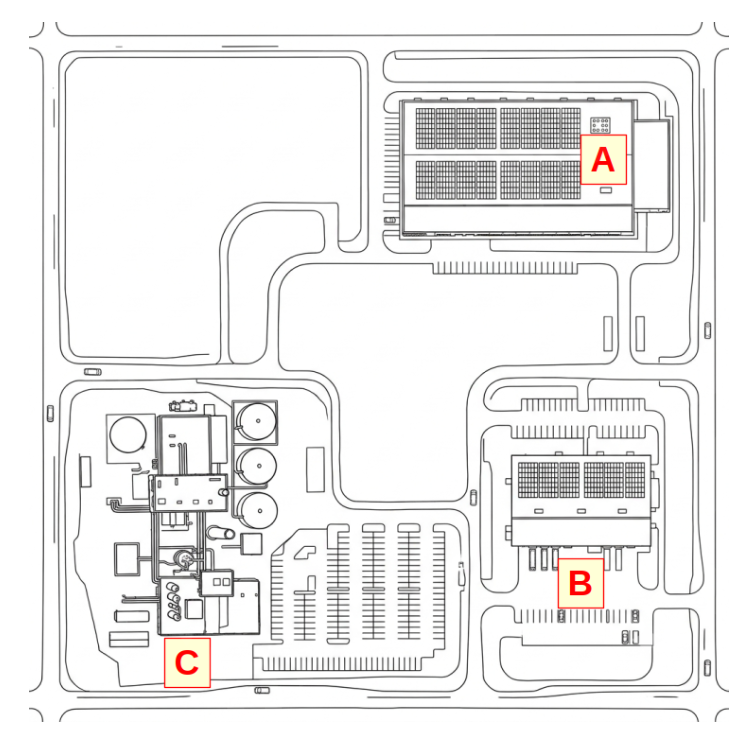

Three factories, A, B, and C, in a 6.0 by 6.0 kilometer industrial complex.  
Source: Assignment sheet 7 from Dr. Karl Kirschner, originally cited as Gemini generated.

### The Data:

The data I will be using is `soil_samples.csv`, which was supplied in the assignment.

The supplied Data file includes three columns:
- the latitude (x),
- the longitude (y),
- the contaminant concentration C(x,y).

It is important to note that the latitude and longitude values are relative to the center of the industrial complex.

***

## Task 1: Data Preparation

The goal of this task is simply to load the `soil_samples.csv` data as a DataFrame and prepare it for the following calculations.  
To do this it will be cleaned by removing duplicate rows and rows with empty values.

In [46]:
input_data = pd.read_csv('soil_samples.csv', header=0, sep=',')
samples = input_data.dropna().drop_duplicates()
removed_rows = len(input_data) - len(samples)

print(f'Loaded {len(samples)} rows.')
print(f'Removed {removed_rows} rows.')

samples.head(10)

Loaded 500 rows.
Removed 0 rows.


,Latitude (meters),Longitude (meters),Concentrations (mg/kg)
0,274.546475,-348.237786,1058.751507
1,225.487078,-659.404473,1121.188691
2,-155.177492,740.428479,306.002181
3,-1144.409587,-555.453236,26.718203
4,-206.499208,907.706669,393.790989
5,441.007705,-644.156001,1219.430205
6,266.752114,-148.522303,804.951156
7,154.904124,-429.994453,1016.263738
8,390.867731,668.775650,78.463438
9,-183.182198,566.828296,103.396012


***

## Task 2: Clustering and Visualization

Text here...

This task can be broken down into 3 subtasks:
- Cluster the data by its latitude and longitude values.
- Add the resulting cluster label to the DataFrame.
- Create a scatter plot of the resulting clusters.

### Clustering the data:

To properly cluster the data, it should be in a seperate Dataframe.  
This Dataframe must be two-dimensional, with one row per soil sample and two columns.  
This is due to K-Means expecting a two-dimensional structure as each sample is represented by a pair of coordinates: $(x_i, y_i)$

In [53]:
coordinate_columns = ['Latitude (meters)', 'Longitude (meters)']
coordinates = samples[coordinate_columns]

if coordinates.shape[1] != 2:
    raise ValueError('K-means requires exactly two coordinate columns.')

if coordinates.isna().any().any():
    raise ValueError('The coordinates contain missing values.')

else:
    print(f'Number of samples: {len(coordinates)}')
    print(f'Coordinate shape: {coordinates.shape}')
    print(f'Missing coordinate values: {coordinates.isna().sum().sum()}')

    coordinates.head(10)

Number of samples: 500
Coordinate shape: (500, 2)
Missing coordinate values: 0


K-Means requires a predetermined number of clusters. As the data refers to three factories, I will forego using the elbow-method analysis and instead be using `3` as my number of clusters.

In [56]:
centroids, labels, inertia = k_means(X=coordinates, n_clusters=3,
                                     random_state=0, n_init='auto')

print(f'Centroids: {centroids}')
print(f'Labels:    {np.unique(labels)}')
print(f'Inertia:   {inertia:.2e}')

Centroids: [[-1000.50162719  -991.90883685]
 [   -2.85194769   990.54255048]
 [  405.97705449  -573.27880011]]
Labels:    [0 1 2]
Inertia:   5.50e+07


***

### Adding the labels to the DataFrame:

Due to additional information in the assignment sheet it is possible to infer that, Cluster 1 corresponds to Building A when using `random_state=0`.

In [60]:
samples['Cluster'] = labels

samples.head(10)

,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster
0,274.546475,-348.237786,1058.751507,2
1,225.487078,-659.404473,1121.188691,2
2,-155.177492,740.428479,306.002181,1
3,-1144.409587,-555.453236,26.718203,0
4,-206.499208,907.706669,393.790989,1
5,441.007705,-644.156001,1219.430205,2
6,266.752114,-148.522303,804.951156,2
7,154.904124,-429.994453,1016.263738,2
8,390.867731,668.775650,78.463438,1
9,-183.182198,566.828296,103.396012,1


In [61]:
counts = (samples['Cluster'].value_counts()
    .sort_index().rename('Number of samples'))

print(counts)

Cluster
0    167
1    167
2    166
Name: Number of samples, dtype: int64


***

### Plotting the Clusters:

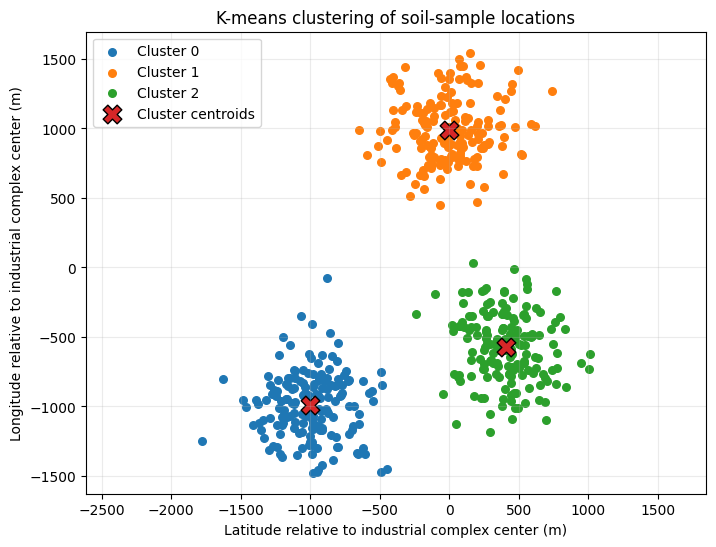

In [63]:
plt.figure(figsize=(8, 6))

for cluster_label in sorted(samples['Cluster'].unique()):
    cluster_data = samples[samples['Cluster'] == cluster_label]

    plt.scatter(x=cluster_data['Latitude (meters)'], 
                y=cluster_data['Longitude (meters)'],
                s=30, label=f'Cluster {cluster_label}')

plt.scatter(x=centroids[:, 0], y=centroids[:, 1],
            marker='X', s=180, edgecolors='black',
            label='Cluster centroids')

plt.xlabel('Latitude relative to industrial-complex center (m)')
plt.ylabel('Longitude relative to industrial-complex center (m)')
plt.title('K-means Clustering of Soil-Sample Locations')


plt.grid(alpha=0.25)
plt.axis('equal')
plt.legend()
plt.show()

The Cluster distribution matches the diagram of the industrial complex buildings based on general location.

***

## Task 3: Model Parameter Optimization for Building A

The goal of this task is to create a user-defined function and use `scipy.optimize.curve_fit`.  

The equation neccessary for this task is supplied in the assignment sheet as the contamination's dispersion pattern:

$ 
C(x,y) = B + A\exp(- \frac{r}{L})
$

where 

$ 
r = \sqrt{(x - x_0)^2 + (y - y_0)^2}.
$

where:

- $C(x,y)$: predicted contaminant concentration at location (x,y) in `milligrams of contaminant per kilogram of soil`,
- $A$: plume amplitude in `milligrams per kilogram`,
- $B$: background concentration in `milligrams per kilogram`,
- $L$: the decay length that controls how quickly the concentration decreases with distance  in `meters`,
- $r$: distance from the contamination source to the point (x,y) in `meters`,
- $x,y$: coordinates of a soil sample in `meters`,
- ($x_0,y_0$): coordinates of the contaminant source in `meters`.


The Assignment provides initial starting guesses:
- $A = 1000$
- $B = 0$
- $x_0 = 0$
- $y_0 = 1000$
- $L = 500$


In [72]:
def plume_model(coordinates: tuple[np.ndarray, np.ndarray] | np.ndarray,
               amplitude: float, background: float, source_latitude: float,
               source_longitude: float, decay_length: float) -> np.ndarray:
    """Calculates contaminant concentrations using the plume model.

        Args:
        coordinates: Tuple containing arrays of latitude and longitude
            coordinates in meters.

        amplitude: Concentration amplitude A in mg/kg.

        background: Background concentration B in mg/kg.

        source_latitude: Estimated latitude coordinate x0 of the
            source in meters.

        source_longitude: Estimated longitude coordinate y0 of the
            source in meters.

        decay_length: Exponential decay length L in meters.

        Returns:
        np.ndarray: Predicted contaminant concentrations in mg/kg.

        Raises:
        ValueError: If the coordinates do not have shape (2, n)
            or the decay length equals zero.
    """
    try:
        coordinate_array = np.asarray(coordinates,
                                      dtype=float)
    except (TypeError, ValueError) as error:
        raise TypeError('Coordinates must contain numeric'
                        'latitude and longitude values.'
                       ) from error
        
        
    if (coordinate_array.ndim != 2 
        or coordinate_array.shape[0] != 2):
        raise ValueError('Coordinates must have shape '
                         '(2, number_of_samples).')

    if decay_length == 0:
        raise ValueError('The decay length must not equal zero.')
    
    latitude, longitude = coordinates

    # Calculate r
    distance_source = np.sqrt((latitude - source_latitude)**2 
                             + (longitude - source_longitude)**2)

    # Calculate C(x,y)
    predicted_concentration = (background + amplitude 
                               * np.exp(-distance_source / decay_length))

    return predicted_concentration

Since this Task specifically focuses on Building A, the below will extract data pertaining to Cluster 1 from the DataFrame and copy it to a new one `a_samples`.  

In [73]:
a_samples = samples.loc[samples['Cluster'] == 1].copy()

print(f'Number of samples assigned to Building A: {len(a_samples)}')
a_samples.head(10)

Number of samples assigned to Building A: 167


,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster
2,-155.177492,740.428479,306.002181,1
4,-206.499208,907.706669,393.790989,1
8,390.867731,668.775650,78.463438,1
9,-183.182198,566.828296,103.396012,1
17,-127.320275,861.803622,461.547412,1
18,87.983579,774.428851,394.394295,1
20,234.028736,964.706228,380.039213,1
25,-382.662638,856.149994,158.814545,1
27,13.373979,1262.605964,332.781797,1
31,-354.860699,1274.500970,113.383554,1


curve_fit requires independent data and dependent data. Luckily the given `.csv` Data supplies both.  
Latitude and longitude are independent data and the measured concentration is dependent data.

Furthermore converting `latitude`, `longitude`, and `concentration` to numpy values makes the calculations easier.

In [74]:
a_latitude = a_samples['Latitude (meters)'].to_numpy()
a_longitude = a_samples['Longitude (meters)'].to_numpy()
a_concentration = a_samples['Concentrations (mg/kg)'].to_numpy()

To test the above user-defined function we will verify that it returns sensible outputs with the assignment's initial guesses.

In [75]:
initial_guesses = [
    1000.0,
    0.0,
    0.0,
    1000.0,
    500.0
]

initial_predictions = plume_model((a_latitude, a_longitude),
                                  *initial_guesses)


print(f'Some initial predictions values: {initial_predictions[:3]},')
print(f'and shape: {initial_predictions.shape}')

Some initial predictions values: [546.16257825 636.11784141 358.91488716],
and shape: (167,)


Now to opimize the parameters

In [12]:
optimized_parameters, parameter_covariance = curve_fit(f=plume_model, xdata=(a_latitude,
                                                                             a_longitude),
                                                       ydata=a_concentration, p0=initial_guesses)

The curve_fit functions returns two objects: `optimized_parameters` and `parameter_covariance`.  
The `optimized_parameters` contain the optimized parameters in the same order as the input `given_data`, therefore we can extract them from that object.

In [78]:
(optimized_amplitude, optimized_background,
optimized_source_latitude, optimized_source_longitude,
optimized_decay_length) = optimized_parameters 

parameter_standard_errors = np.sqrt(
    np.diag(parameter_covariance))

In [79]:
parameter_names = ['Amplitude A', 'Background B',
                   'Source latitude x0', 'Source longitude y0',
                   'Decay length L']

parameter_units = ['mg/kg', 'mg/kg', 'm', 'm', 'm']

optimized_parameter_table = pd.DataFrame({
    'Parameter': parameter_names,'Optimized value': optimized_parameters,
    'Standard error': parameter_standard_errors, 'Unit': parameter_units})

optimized_parameter_table

,Parameter,Optimized value,Standard error,Unit
0,Amplitude A,1210.912911,64.784863,mg/kg
1,Background B,-484.950640,71.662323,mg/kg
2,Source latitude x0,-4.801459,2.429690,m
3,Source longitude y0,986.975875,2.347507,m
4,Decay length L,684.479060,64.098238,m


The initial predictions given in the assignment were not too far off of the optimized parameters with the exception of the background contamination which the initial prediction put at 0.0. A negative background contamination is physically not plausable as an actual contaminant concentration. This suggests that the simple exponential model uses the background parameter partly to compensate for deviations between the assumed radial plume shape and the observed data.

This is partly due to how `curve_fit` functions and the given instructions as they specified starting values but not parameter bounds.

***

## Task 4: Predict Building A's Contaminant Concentration and Visualize

The goal of this task is to use the optimized values from Task 3 to predict contamination around Building A, then plot the predicted contamination against the real contamination from the `soil_samples.csv` file.

In [80]:
a_predictions = plume_model((a_latitude, a_longitude), *optimized_parameters)

print('First five measured concentrations:')
print(a_concentration[:5])

print('\nFirst five predicted concentrations:')
print(a_predictions[:5])

First five measured concentrations:
[306.00218089 393.79098875  78.46343816 103.39601164 461.54741151]

First five predicted concentrations:
[309.15816852 397.33522522  91.75465769 136.63705384 452.56723663]


Adding the predicted values to `a_samples` makes the comparison easier to inspect and to document. Furthermore we can calculate the residual which can be used to determine how well the model predicted the contamination: a positive residual means the model underpredicts the measurements, a negative residual mean the model overpredicts the measurement, and a residual near zero means the prediction is close to the measurement.

In [17]:
a_samples['Predicted Concentration (mg/kg)'] = a_predictions

a_samples['Residual (mg/kg)'] = (a_samples['Concentrations (mg/kg)']
                                 - a_samples['Predicted Concentration (mg/kg)'])

a_samples.head(10)

,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster,Predicted Concentration (mg/kg),Residual (mg/kg)
2,-155.177492,740.428479,306.002181,1,309.158169,-3.155988
4,-206.499208,907.706669,393.790989,1,397.335225,-3.544236
8,390.867731,668.775650,78.463438,1,91.754658,-13.291220
9,-183.182198,566.828296,103.396012,1,136.637054,-33.241042
17,-127.320275,861.803622,461.547412,1,452.567237,8.980175
18,87.983579,774.428851,394.394295,1,377.957119,16.437176
20,234.028736,964.706228,380.039213,1,367.993168,12.046045
25,-382.662638,856.149994,158.814545,1,190.200466,-31.385921
27,13.373979,1262.605964,332.781797,1,323.863659,8.918138
31,-354.860699,1274.500970,113.383554,1,139.771868,-26.388314


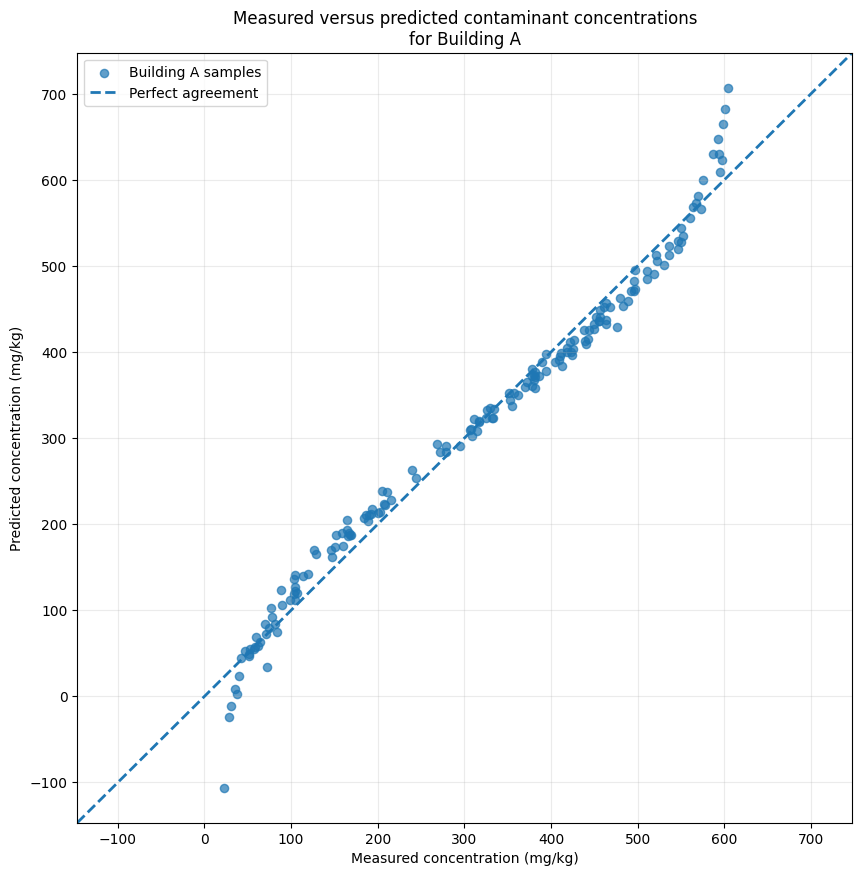

In [22]:
plot_min = min(a_concentration.min(), 
               a_predictions.min())
plot_max = max(a_concentration.max(), 
               a_predictions.max())

plot_range = plot_max - plot_min
plot_pad = 0.05 * plot_range

axis_lim = [plot_min - plot_pad, 
               plot_max + plot_pad]

plt.figure(figsize=(10, 10))

plt.scatter(a_concentration, a_predictions, s=35,
            alpha=0.7, label='Building A samples')

plt.plot(axis_lim, axis_lim,
         linestyle='--', linewidth=2, 
         label='Perfect agreement')

plt.xlabel('Measured concentration (mg/kg)')
plt.ylabel('Predicted concentration (mg/kg)')
plt.title('Measured versus predicted contaminant concentrations\n'
          'for Building A')

plt.xlim(axis_lim)
plt.ylim(axis_lim)

plt.grid(alpha=0.25)
plt.legend()
plt.show()

The above plot shows how close the predicted values are to the measured concentration.
Points close to the identity line represent points where the model prediction is close to the measured concentration. Points above the identity line mean the predicted value is greater than the measured value. Points below the identity line mean the predicted value is less than the measured value.

The shape of the predicted values against the measured samples display the fact, that the simple radial exponential equation does not capture the complete concentration pattern.

***

## Task 5: Short Interpretation and Summary

to be written...

***

References:

[1]

[2]

[3]